C:\Users\Aayush Kuthe\AppData\Local\Temp\ipykernel_21852\1302326208.py:11: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv('Interest Rates and Savings Rate.csv', parse_dates=['Date'])


R² Score: 1.00
RMSE: 0.09


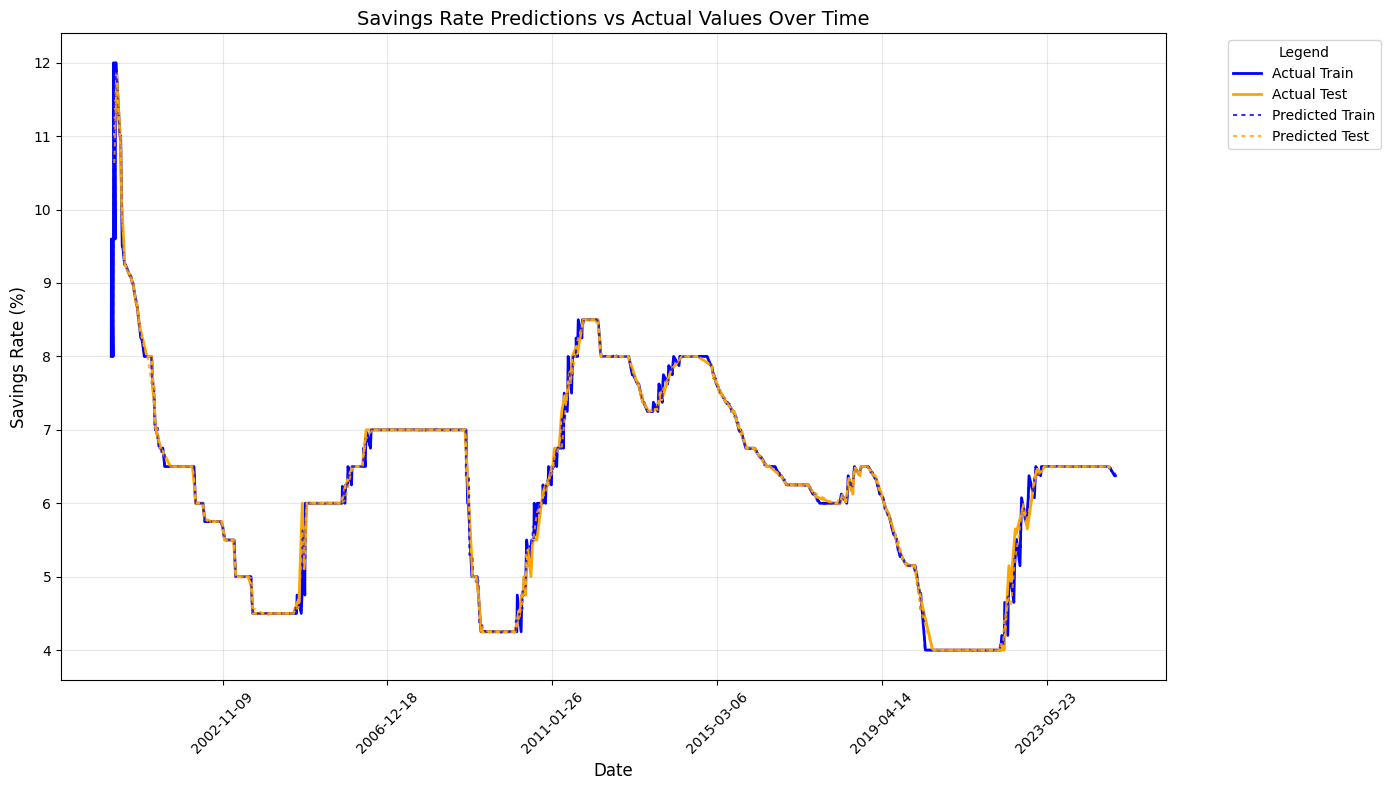

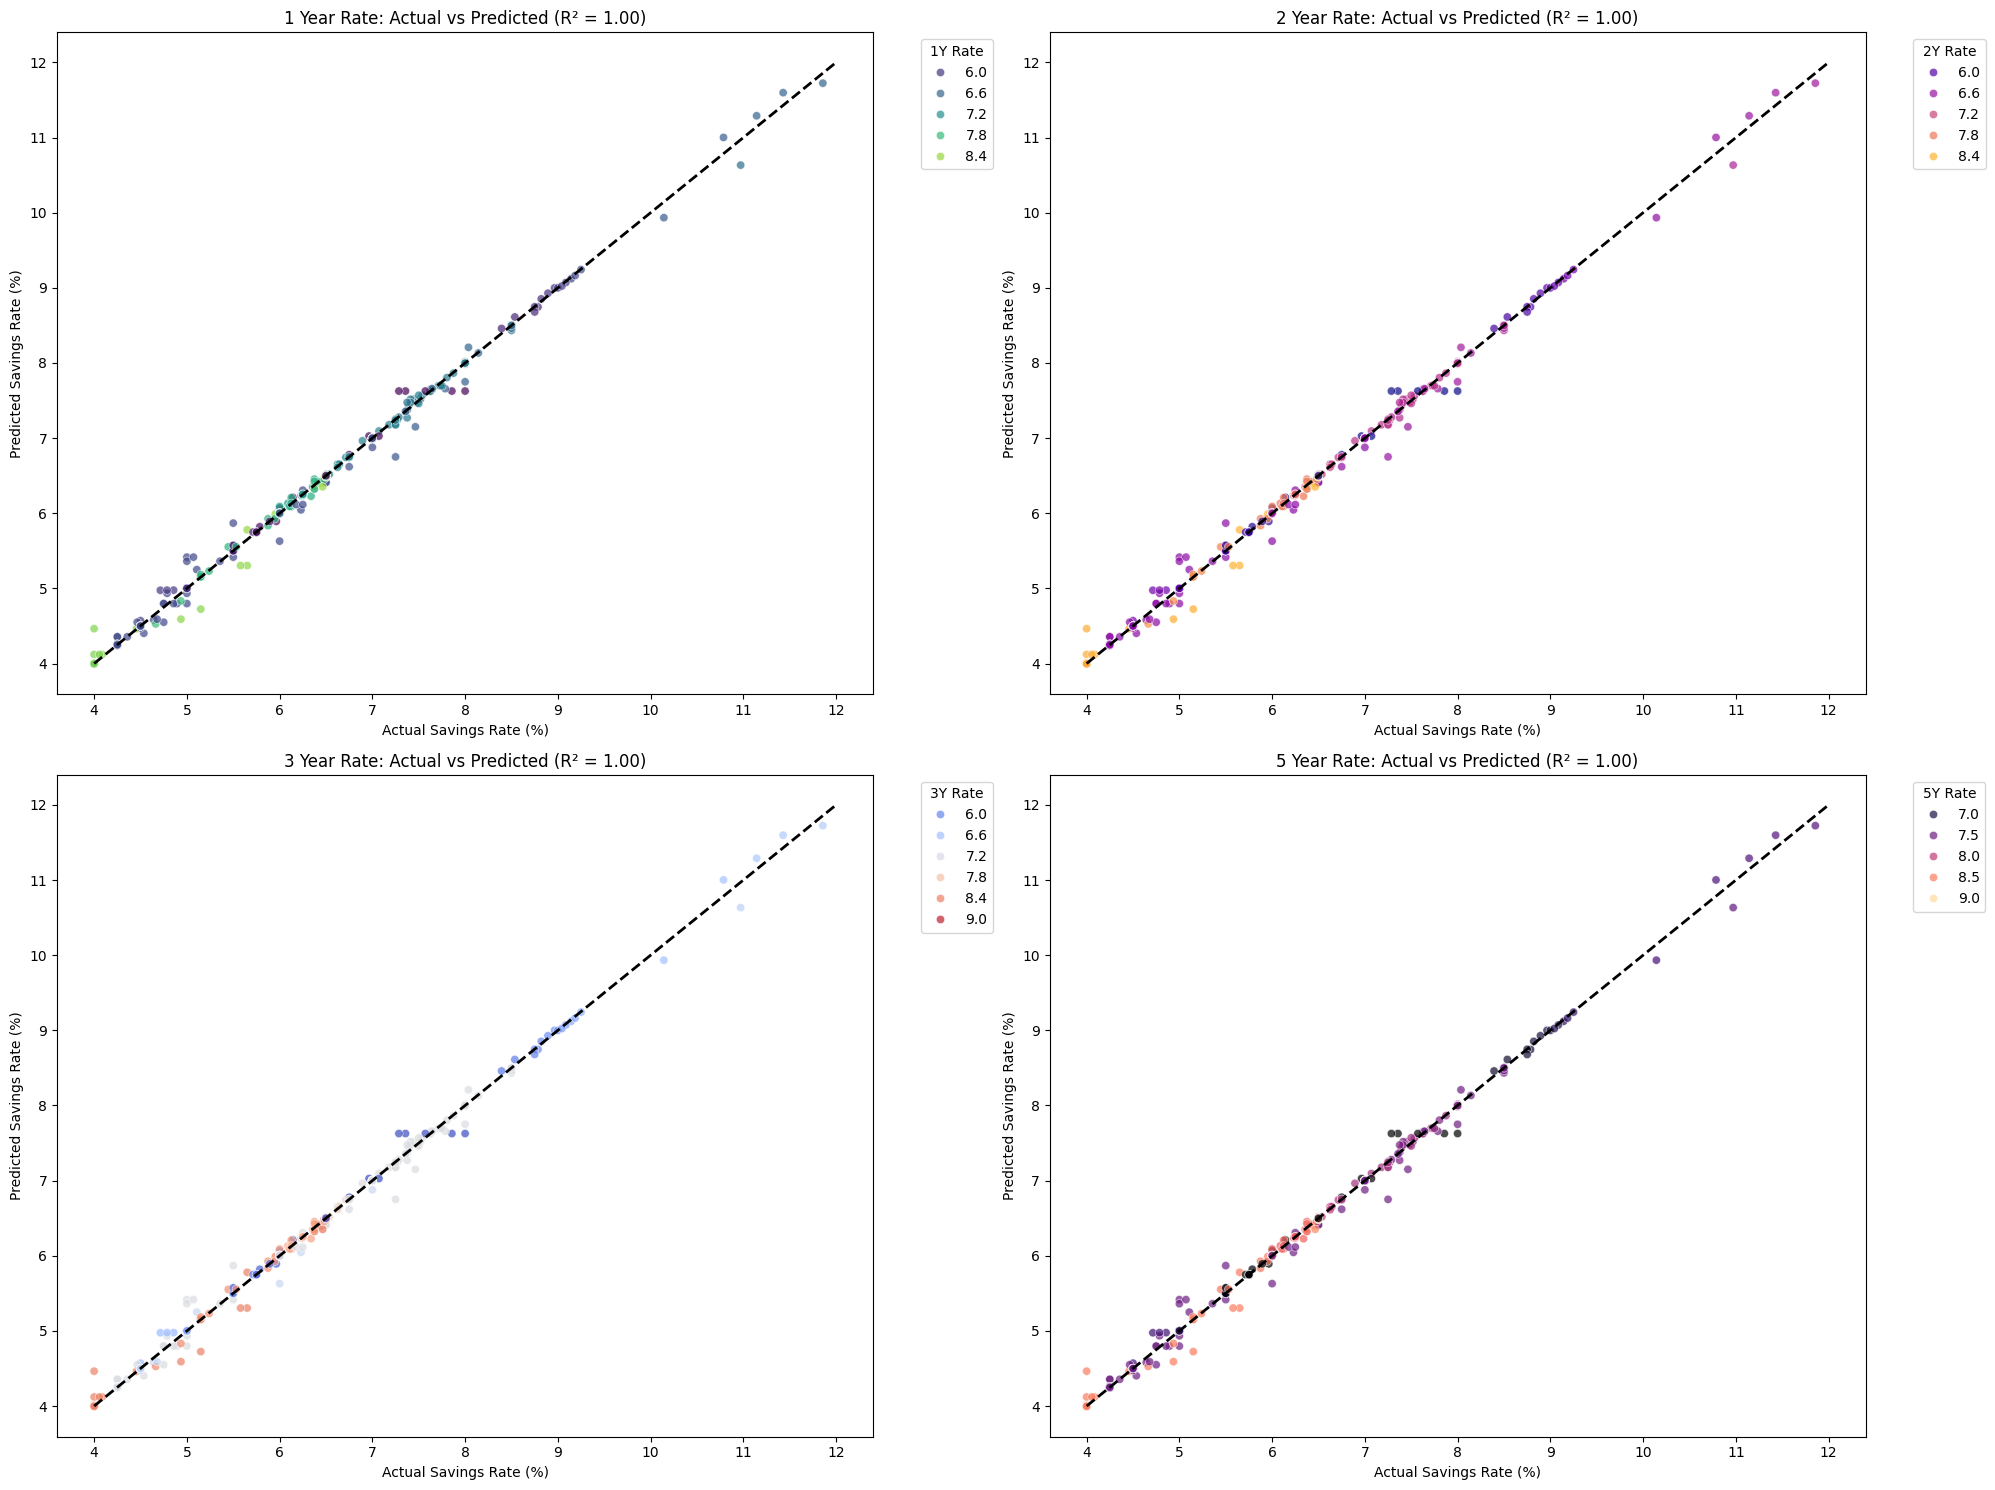

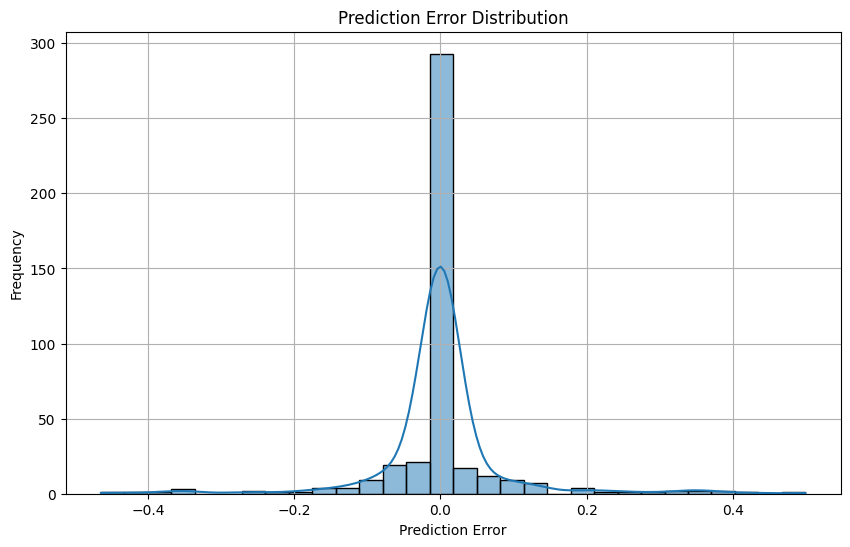

<Figure size 1000x600 with 0 Axes>

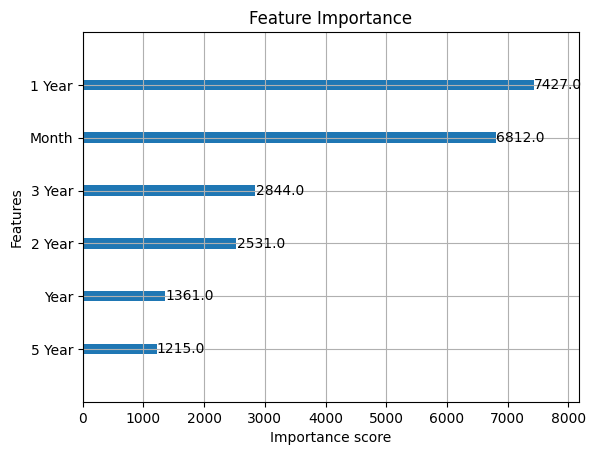

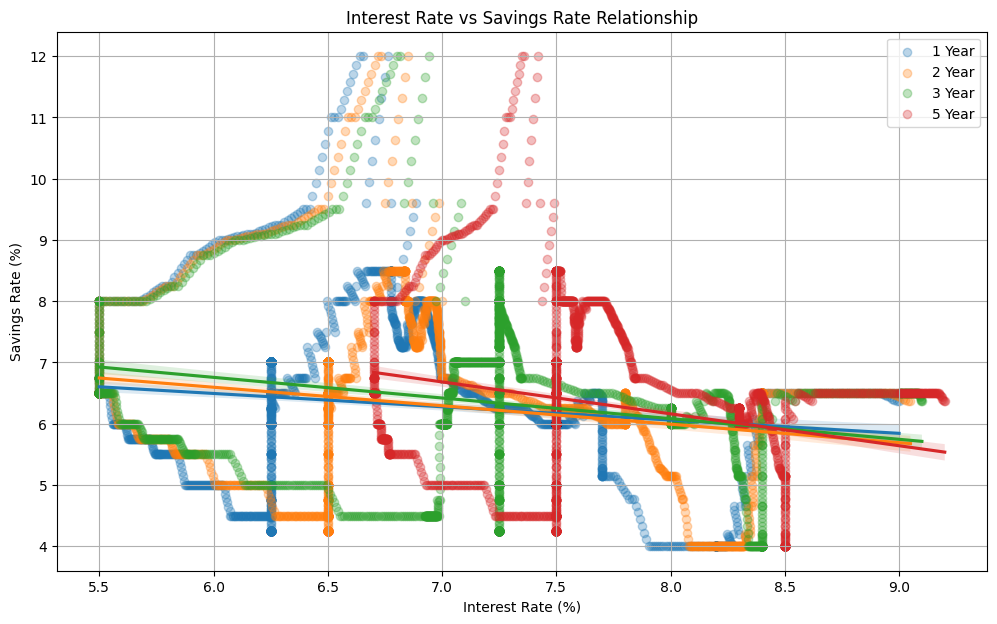

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb
import joblib

# Load and prepare data
df = pd.read_csv('Interest Rates and Savings Rate.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Feature engineering
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Define features and target
X = df[['1 Year', '2 Year', '3 Year', '5 Year', 'Year', 'Month']]
y = df['Average']  # Assuming 'Average' represents savings rate

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost model
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    early_stopping_rounds=50,
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# Save model
joblib.dump(model, 'savings_rate_model.pkl')

# Predictions
y_pred = model.predict(X_test)

# Calculate metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R² Score: {r2:.2f}')
print(f'RMSE: {rmse:.2f}')

# ========== Time Series Comparison Plot ==========
# Add date information to the test set
X_test_with_date = X_test.copy()
X_test_with_date['Date'] = df.loc[X_test.index, 'Date']
y_test_with_date = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'Date': X_test_with_date['Date']})

# Create full date range predictions
full_data = df[['Date', 'Average']].copy()
full_data['Type'] = 'Actual Train'
full_data.loc[X_test.index, 'Type'] = 'Actual Test'

# Create predictions dataframe
train_preds = pd.DataFrame({
    'Date': df.loc[X_train.index, 'Date'],
    'Predicted': model.predict(X_train),
    'Type': 'Predicted Train'
})

test_preds = pd.DataFrame({
    'Date': y_test_with_date['Date'],
    'Predicted': y_test_with_date['Predicted'],
    'Type': 'Predicted Test'
})

# Combine all data
plot_data = pd.concat([
    full_data[['Date', 'Average', 'Type']].rename(columns={'Average': 'Value'}),
    train_preds.rename(columns={'Predicted': 'Value'}),
    test_preds.rename(columns={'Predicted': 'Value'})
])

# Create time series plot
plt.figure(figsize=(14, 8))

# Plot actual values
sns.lineplot(data=plot_data[plot_data['Type'].str.contains('Actual')], 
             x='Date', y='Value', hue='Type',
             style='Type', dashes=False,
             palette={'Actual Train': 'blue', 'Actual Test': 'orange'},
             linewidth=2)

# Plot predicted values
sns.lineplot(data=plot_data[plot_data['Type'].str.contains('Predicted')], 
             x='Date', y='Value', hue='Type',
             style='Type', dashes=[(2,2), (2,2)],
             palette={'Predicted Train': 'blue', 'Predicted Test': 'orange'},
             linewidth=1.5, alpha=0.8)

plt.title('Savings Rate Predictions vs Actual Values Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Savings Rate (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')

# Format x-axis dates
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('time_series_comparison.png')
plt.show()

# ========== Existing Visualizations ==========
# Actual vs Predicted Plots for Each Term
plt.figure(figsize=(20, 15))

# 1-Year Rate Plot
plt.subplot(2, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, hue=X_test['1 Year'], palette='viridis', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual Savings Rate (%)')
plt.ylabel('Predicted Savings Rate (%)')
plt.title(f'1 Year Rate: Actual vs Predicted (R² = {r2:.2f})')
plt.legend(title='1Y Rate', bbox_to_anchor=(1.05, 1), loc='upper left')

# 2-Year Rate Plot
plt.subplot(2, 2, 2)
sns.scatterplot(x=y_test, y=y_pred, hue=X_test['2 Year'], palette='plasma', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual Savings Rate (%)')
plt.ylabel('Predicted Savings Rate (%)')
plt.title(f'2 Year Rate: Actual vs Predicted (R² = {r2:.2f})')
plt.legend(title='2Y Rate', bbox_to_anchor=(1.05, 1), loc='upper left')

# 3-Year Rate Plot
plt.subplot(2, 2, 3)
sns.scatterplot(x=y_test, y=y_pred, hue=X_test['3 Year'], palette='coolwarm', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual Savings Rate (%)')
plt.ylabel('Predicted Savings Rate (%)')
plt.title(f'3 Year Rate: Actual vs Predicted (R² = {r2:.2f})')
plt.legend(title='3Y Rate', bbox_to_anchor=(1.05, 1), loc='upper left')

# 5-Year Rate Plot
plt.subplot(2, 2, 4)
sns.scatterplot(x=y_test, y=y_pred, hue=X_test['5 Year'], palette='magma', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual Savings Rate (%)')
plt.ylabel('Predicted Savings Rate (%)')
plt.title(f'5 Year Rate: Actual vs Predicted (R² = {r2:.2f})')
plt.legend(title='5Y Rate', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('term_actual_vs_predicted.png')
plt.show()

# Error Distribution
errors = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(errors, kde=True, bins=30)
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Prediction Error Distribution')
plt.grid(True)
plt.savefig('error_distribution.png')
plt.show()

# Feature Importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, importance_type='weight')
plt.title('Feature Importance')
plt.savefig('feature_importance.png')
plt.show()

# Interest Rate vs Savings Rate Relationships
plt.figure(figsize=(12, 7))
for col in ['1 Year', '2 Year', '3 Year', '5 Year']:
    sns.regplot(x=df[col], y=df['Average'], label=col, scatter_kws={'alpha':0.3})
plt.xlabel('Interest Rate (%)')
plt.ylabel('Savings Rate (%)')
plt.title('Interest Rate vs Savings Rate Relationship')
plt.legend()
plt.grid(True)
plt.savefig('interest_vs_savings.png')
plt.show()